#### Load green coffee beans production worldwide

I used United Nations - FAOSTAT API to load worldwide production index

In [ ]:
#!pip install faostat

In [94]:
path_img  = "C:/Users/canzolbr/Documents/GitHub/Forecasting-World-Coffee-Prices/Images/"

In [3]:
import faostat
faostat.set_requests_args(token='eyJraWQiOiJVSFE2dmwrekFTaGRpSGpsOFFSK0d2ZW13RWIzSjZNdytYNTRURXZtNUNJPSIsImFsZyI6IlJTMjU2In0.eyJzdWIiOiJlOGRhMDdhZi1jODBkLTRjN2QtOWFiZS1iZGUyNTJjY2QyMmYiLCJpc3MiOiJodHRwczpcL1wvY29nbml0by1pZHAuZXUtd2VzdC0xLmFtYXpvbmF3cy5jb21cL2V1LXdlc3QtMV9iTkVMTk9DMnYiLCJ2ZXJzaW9uIjoyLCJjbGllbnRfaWQiOiIyY3NsdHNpZ2FvODVpdmhwNm9qcDFhaWM3byIsIm9yaWdpbl9qdGkiOiJiMjhkM2ViZi0wN2VkLTRmNGMtOWFhMS03ZTQ2M2FkOTU0OWQiLCJldmVudF9pZCI6ImNlM2JiNzk1LTc1ZTEtNDI3OC1hNzY0LWQ4MWZkMThlOTg5ZiIsInRva2VuX3VzZSI6ImFjY2VzcyIsInNjb3BlIjoiYXdzLmNvZ25pdG8uc2lnbmluLnVzZXIuYWRtaW4gcGhvbmUgb3BlbmlkIHByb2ZpbGUgZW1haWwiLCJhdXRoX3RpbWUiOjE3NzQ5MDYyMzksImV4cCI6MTc3NDkwOTgzOSwiaWF0IjoxNzc0OTA2MjM5LCJqdGkiOiIzYjZhYjcxNS03YWQ0LTRmYTgtOThmMS05MTVhMGFkY2M2OTkiLCJ1c2VybmFtZSI6IkNlc2FyQW56b2xhQnJhdm8ifQ.Nvz1gEnIuvu5hWfkGM3jFoHQ9XSPmcdiSJzU-T4HkP0JdcSJFeLEKETshceGpsrZr1FHIvL346OFvrtcyQQcLokkT6LjFqEmY74sF9c6wivhEzcIK2nqCndDwowCk1JZr0s8knPUkWLVL4xMhi3ilQll-UW2Qhg27rqwpsS7kC_WeCRQ7iww5kscvZJwsly6DSLfY7zlG4igulP3Ez_gQYlUqUuuKsPH9DbhWY2nFXv5ZFRY7ZJ2nAJmUc3A6jmzSzEMWaoZ5OtIknoGld7nF4FpKPKQxoI7QV0cDfshnlr942E4gXpcH4PyN4g8N8sn_PS98J7n8EMgLXFPW3aogw')

In [4]:
faostat.list_datasets_df()

,code,label,date_update,note_update,release_current,state_current,year_current,release_next,state_next,year_next
0,QCL,Crops and livestock products,2025-12-31,,2025-12-31,final,2024,2026-12,final,2025
1,QI,Production Indices,2026-02-09,,2026-02-09,final,2024,2027-02,final,2025
2,QV,Value of Agricultural Production,2026-02-09,,2026-02-09,final,2024,2027-02,final,2025
3,FS,Suite of Food Security Indicators,2025-07-28,,2025-07-28,final,2024,2026-07,final,2025
4,FBS,Food Balances (2010-),2025-10-28,,2025-10-28,final,2023,2026-10,final,2024
...,...,...,...,...,...,...,...,...,...,...
63,FA,Food Aid Shipments (WFP),2016-12-22,,2016-12-22,preliminary,2016,,,
64,RM,Machinery,2021-12-03,minor revision,2011-12-22 / 2021-12-03,final,2009,,,
65,RY,Machinery Archive,2021-12-03,minor revision,2006-12-31 / 2021-12-03,final,2005,,,
66,RA,Fertilizers archive,2020-09-08,minor revision,2013-12-31 / 2020-09-08,final,2002,,,


In [5]:
faostat.list_pars('QI')

[('parameter code', 'coding_systems', 'subdimensions {code: meaning}'),
 ('area',
  ['M49', 'FAO', 'ISO2', 'ISO3'],
  {'countries': 'Countries',
   'regions': 'Regions',
   'specialgroups': 'Special Groups'}),
 ('element', [], {'elements': 'Elements'}),
 ('item', ['CPC', 'FAO'], {'itemsagg': 'Items Aggregated'}),
 ('year', [], {'years': 'Years'})]

In [45]:

# COFFEE BEANS correspond to item code 656 in FAOSTAT Crops Primary dataset (QC)
# Element code 5510 = Production (tonnes)
mypars   = {'item':'656'}
mycoding = {'area': 'FAO'}
df       = faostat.get_data_df('QCL', pars=mypars, coding=mycoding)

In [48]:
df_prod = df[(df['Element']=='Production') & (df['Year']=='2024')]

In [53]:
df_prod['Area Code (FAO)'] = df_prod['Area Code (FAO)'].astype(int)

C:\Users\canzolbr\AppData\Local\Temp\ipykernel_16864\2062879632.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_prod['Area Code (FAO)'] = df_prod['Area Code (FAO)'].astype(int)


In [58]:
df_prod = df_prod[df_prod['Area Code (FAO)']<5000]

In [64]:
df_prod['Value'] = df_prod['Value'].astype(float) 

C:\Users\canzolbr\AppData\Local\Temp\ipykernel_16864\1668647672.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_prod['Value'] = df_prod['Value'].astype(float)


In [68]:
df_prod['prod_share'] = df_prod['Value']/df_prod['Value'].sum()

C:\Users\canzolbr\AppData\Local\Temp\ipykernel_16864\1338264391.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_prod['prod_share'] = df_prod['Value']/df_prod['Value'].sum()


In [73]:
df_prod = df_prod.sort_values('prod_share',ascending=False)

In [83]:
df_prod_top = df_prod.head(7)

In [84]:
df_prod_top['prod_share'].sum()

np.float64(0.7460049341531438)

* 7 countries produce 3/4 of global coffee bean production

* Lets graph the shares

In [90]:
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
sns

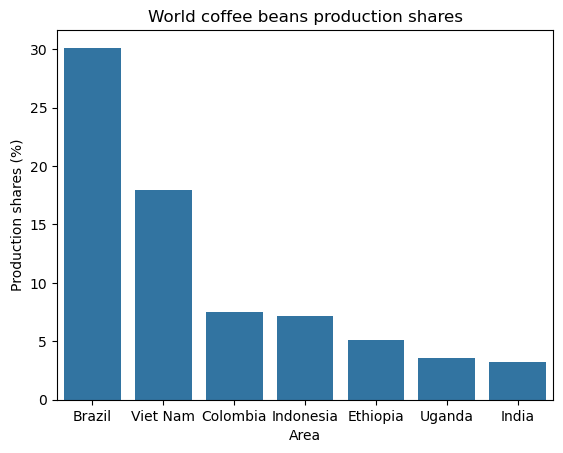

In [95]:
sns.barplot( y = df_prod_top['prod_share']*100, x = df_prod_top['Area'])
plt.ylabel('Production shares (%)')
plt.title('World coffee beans production shares')
plt.savefig(path_img + "coffee_beans_prodshare.png")